In [11]:
import re
from typing import List, Tuple
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# 1. Load cleaned Stephen King novels
# ------------------------------------------------------------------

# Use the cleaned versions you produced earlier
pet_text     = Path("../data/PetSemetary_clean.txt").read_text(encoding="utf-8")
shining_text = Path("../data/TheShining_clean.txt").read_text(encoding="utf-8")

print(f"Pet Sematary characters: {len(pet_text):,}")
print(f"The Shining characters:   {len(shining_text):,}")


Pet Sematary characters: 803,956
The Shining characters:   898,577


In [12]:
def split_into_paragraphs(text: str, min_words: int = 10) -> List[str]:
    """
    Split raw text into paragraphs using blank lines as boundaries.
    Filters out very short paragraphs (e.g. headings).
    """
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    raw_paras = re.split(r'\n\s*\n+', text)
    paras = []
    for p in raw_paras:
        cleaned = re.sub(r'\s+', ' ', p).strip()
        if not cleaned:
            continue
        if len(cleaned.split()) < min_words:
            continue
        paras.append(cleaned)
    return paras

pet_paras     = split_into_paragraphs(pet_text)
shining_paras = split_into_paragraphs(shining_text)

print(f"Pet Sematary paragraphs: {len(pet_paras)}")
print(f"The Shining paragraphs:   {len(shining_paras)}")

# ------------------------------------------------------------------
# 3. Discourse marker list adapted for narrative/horror
# ------------------------------------------------------------------

DISCOURSE_MARKERS = [
    # contrast / concession
    "however", "although", "though", "even though", "nevertheless", "nonetheless",
    "in contrast", "on the other hand", "instead", "after all",
    # cause / result
    "because", "therefore", "so", "thus", "as a result",
    # temporal / narrative flow
    "meanwhile", "suddenly", "then", "afterwards", "before", "later",
    "at the same time", "finally"
]

def count_markers(paragraph: str) -> int:
    """
    Count occurrences of all discourse markers in a paragraph (case-insensitive).
    Multi-word markers are matched as substrings.
    """
    text = paragraph.lower()
    count = 0
    for m in DISCOURSE_MARKERS:
        count += text.count(m)
    return count

def marker_density(paragraphs: List[str]) -> Tuple[list, list]:
    """
    For each paragraph, compute:
      - marker density = (# markers) / (# words)
      - paragraph length in words

    Returns:
      densities: list[float]
      lengths:   list[int]
    """
    densities = []
    lengths = []
    for p in paragraphs:
        words = re.findall(r"\w+", p)
        n_words = len(words)
        if n_words == 0:
            continue
        markers = count_markers(p)
        densities.append(markers / n_words)
        lengths.append(n_words)
    return densities, lengths

Pet Sematary paragraphs: 153
The Shining paragraphs:   451


In [13]:
pet_dens, pet_len         = marker_density(pet_paras)
shining_dens, shining_len = marker_density(shining_paras)

mean_pet     = sum(pet_dens) / len(pet_dens)
mean_shining = sum(shining_dens) / len(shining_dens)

print(f"Pet Sematary mean discourse markers per word: {mean_pet:.5f}")
print(f"The Shining mean discourse markers per word:   {mean_shining:.5f}")

Pet Sematary mean discourse markers per word: 0.02363
The Shining mean discourse markers per word:   0.02077


Why are several different paths visible?

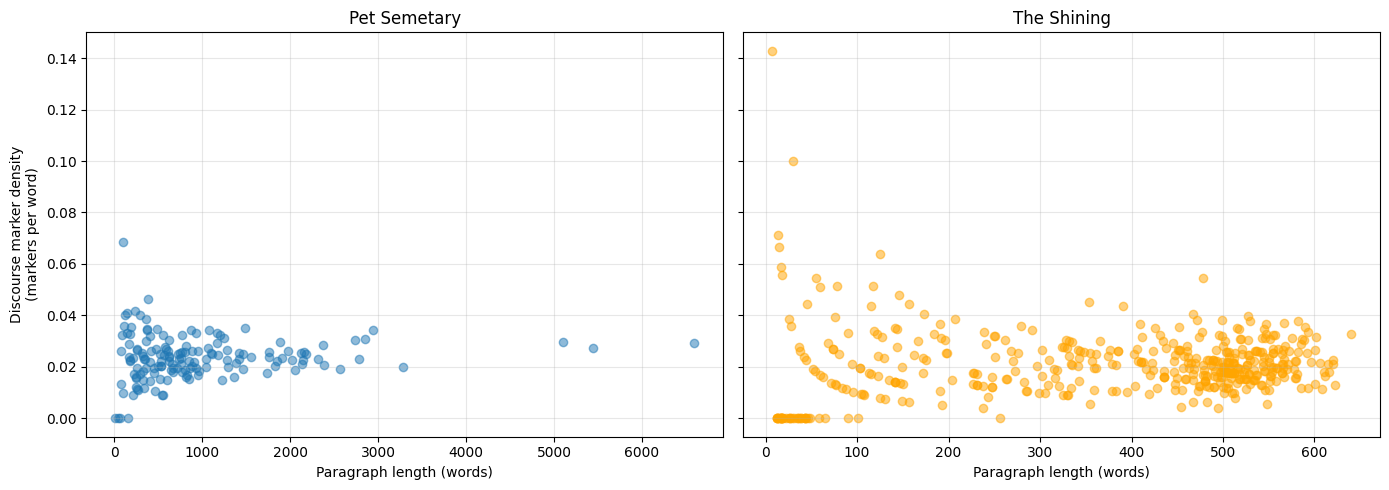

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(pet_len, pet_dens, alpha=0.5)
axes[0].set_title('Pet Semetary')
axes[0].set_xlabel('Paragraph length (words)')
axes[0].set_ylabel('Discourse marker density\n(markers per word)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(shining_len, shining_dens, alpha=0.5, color="orange")
axes[1].set_title('The Shining')
axes[1].set_xlabel('Paragraph length (words)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


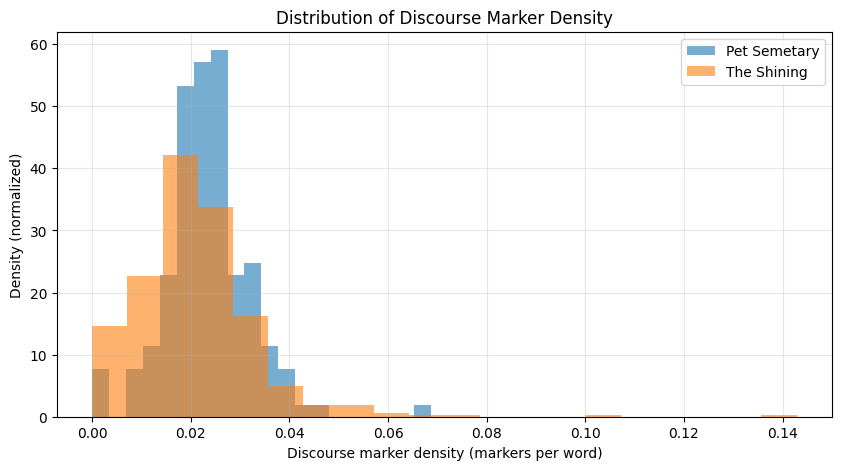

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(pet_dens,     bins=20, alpha=0.6, label='Pet Semetary', density=True)
ax.hist(shining_dens, bins=20, alpha=0.6, label='The Shining', density=True)
ax.set_xlabel('Discourse marker density (markers per word)')
ax.set_ylabel('Density (normalized)')
ax.set_title('Distribution of Discourse Marker Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

#### Histogram (Distribution Comparison)

**What you're seeing:**
- This shows HOW COMMON different density levels are
- **X-axis**: Marker density ranges
- **Y-axis**: How frequently that density occurs (normalized so both books are comparable)

**Key Observations:**

1. **Tall Peak Near Zero**:
   - The huge spike at the left (around 0.00) means MOST paragraphs have zero or very few markers
   - Both books are dominated by simple, direct narrative prose

2. **Long Right Tail**:
   - The gradual decline to the right shows that higher densities are increasingly rare
   - Very few paragraphs exceed 0.04 density

3. **Both Books Overlap Almost Perfectly**:
   - The blue (Wonderland) and orange (Looking-Glass) distributions are nearly identical
   - This confirms Carroll had a very consistent writing style

**What Would Be Different?**
- **Academic paper**: Would have a peak around 0.02-0.04 (much higher)
- **News article**: Peak around 0.01-0.02 (moderate)
- **Children's book (like this)**: Peak at 0.00-0.01 (low, as we see)

---

### What This Tells Us About Lewis Carroll's Writing

1. **Narrative-First Style**: Carroll focuses on storytelling through action and dialogue rather than explicit logical connections

2. **Accessible Language**: Low marker density makes the text easier to read - perfect for his young audience

3. **Consistent Voice**: Both books show identical patterns, suggesting a deliberate, polished style

4. **Strategic Marker Use**: The few high-density paragraphs likely mark important moments where Carroll wants to emphasize logical connections or contrasts

### Application to Your Own Projects

**If you're analyzing text:**
- High marker density → formal, structured, argumentative
- Low marker density → narrative, conversational, descriptive
- Use this to automatically classify text type or writing style

**If you're generating text (with AI or manually):**
- Fiction/stories: Keep density low (like Carroll)
- Explanations/tutorials: Use moderate density for clarity
- Academic/business: Use higher density for professional tone